### Importación de librerías

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Carga del dataset

In [52]:
# Intentar importar google.colab para detectar si estamos en Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # En Colab: pedimos que suban el archivo manualmente
    print("Ejecutando en Google Colab. Por favor, sube el archivo 'teen_phone_addiction.csv'")
    uploaded = files.upload()
    # El archivo se guarda en el directorio actual
    dataset_path = 'teen_phone_addiction.csv'
else:
    # En local: asumimos que el notebook está en 'notebooks/' y el dataset en '../dataset/'
    # Si no se encuentra, intentamos otras rutas comunes
    possible_paths = [
        os.path.join('..', 'dataset', 'teen_phone_addiction.csv'),
        os.path.join('dataset', 'teen_phone_addiction.csv'),   # por si acaso
        'teen_phone_addiction.csv'                            # si está en la misma carpeta
    ]
    dataset_path = None
    for path in possible_paths:
        if os.path.exists(path):
            dataset_path = path
            break

if dataset_path is None or not os.path.exists(dataset_path):
    raise FileNotFoundError(
        "No se encontró 'teen_phone_addiction.csv'. En local se espera en '../dataset/'. "
        "En Colab, súbelo cuando se solicite."
    )

df = pd.read_csv(dataset_path)
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Ruta utilizada: {dataset_path}")
df.head(3)

Ejecutando en Google Colab. Por favor, sube el archivo 'teen_phone_addiction.csv'


Saving teen_phone_addiction.csv to teen_phone_addiction (3).csv
Dataset cargado: 3000 filas x 25 columnas
Ruta utilizada: teen_phone_addiction.csv


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2


### Limpieza y separación de variables

In [53]:
# Eliminamos columnas irrelevantes
columns_to_drop = ['ID', 'Name', 'Location']
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

target_col = 'Addiction_Level'
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# Identificar tipos de columnas
categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_raw.select_dtypes(exclude=['object']).columns.tolist()

print(f"Variables predictoras: {len(X_raw.columns)}")
print(f"Categóricas: {categorical_cols}")
print(f"Numéricas:   {numeric_cols}")

Variables predictoras: 21
Categóricas: ['Gender', 'School_Grade', 'Phone_Usage_Purpose']
Numéricas:   ['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']


### Preprocesamiento (One‑Hot Encoding, SIN escalar)

In [54]:
# Al no escalar, los coeficientes se interpretan en las unidades originales.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Ajustamos el preprocesador y transformamos los datos
X_processed = preprocessor.fit_transform(X_raw)
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()

# Obtener los nombres de las columnas después del preprocesamiento
# Esto es esencial para interpretar los coeficientes
feature_names = preprocessor.get_feature_names_out()

print(f"Dimensiones después de One-Hot Encoding: {X_processed.shape}")
print(f"Número de características: {len(feature_names)}")

Dimensiones después de One-Hot Encoding: (3000, 29)
Número de características: 29


### División en entrenamiento y prueba

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 2400 muestras
Prueba:        600 muestras


### Entrenamiento del modelo de Regresión Lineal

In [56]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

print("Entrenamiento completado.")
print(f"Intercepto (término independiente): {modelo_lr.intercept_:.4f}")

Entrenamiento completado.
Intercepto (término independiente): 3.7135


In [57]:
# Recortar predicciones a [0, 10]
y_pred = np.clip(y_pred, 0, 10)

# Recalcular métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE corregido: {mae:.3f}")
print(f"R² corregido:  {r2:.3f}")

MAE corregido: 0.472
R² corregido:  0.826


### Verificar predicciones fuera de rango

In [58]:
print(f"Predicción mínima: {y_pred.min():.2f}")
print(f"Predicción máxima: {y_pred.max():.2f}")
print(f"Número de predicciones < 0:  {(y_pred < 0).sum()}")
print(f"Número de predicciones > 10: {(y_pred > 10).sum()}")

Predicción mínima: 5.21
Predicción máxima: 10.00
Número de predicciones < 0:  0
Número de predicciones > 10: 0


### Extracción y ordenamiento de coeficientes (importancia)

In [59]:
coeficientes = modelo_lr.coef_

# Creamos un DataFrame con los nombres y coeficientes
coef_df = pd.DataFrame({
    'Característica': feature_names,
    'Coeficiente': coeficientes,
    'Valor_Absoluto': np.abs(coeficientes)
}).sort_values('Valor_Absoluto', ascending=False)

# Mostramos los 20 más importantes
print("🔝 TOP 20 variables más influyentes (por valor absoluto del coeficiente):")
coef_df.head(20)

🔝 TOP 20 variables más influyentes (por valor absoluto del coeficiente):


,Característica,Coeficiente,Valor_Absoluto
1,num__Daily_Usage_Hours,0.499082,0.499082
14,num__Time_on_Gaming,0.487521,0.487521
13,num__Time_on_Social_Media,0.484260,0.484260
2,num__Sleep_Hours,-0.249709,0.249709
12,num__Apps_Used_Daily,0.106833,0.106833
18,cat__Gender_Male,-0.070966,0.070966
9,num__Parental_Control,-0.057615,0.057615
23,cat__School_Grade_8th,0.037210,0.037210
20,cat__School_Grade_11th,0.034597,0.034597
10,num__Screen_Time_Before_Bed,-0.033049,0.033049


### Visualización de los coeficientes más relevantes

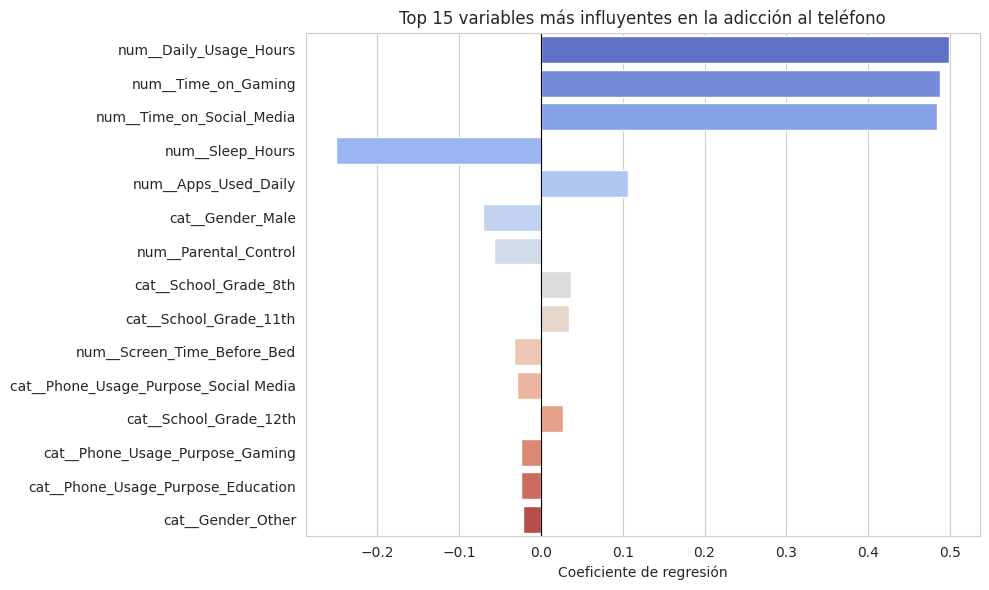

In [60]:
top_n = 15  # número de variables a mostrar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(top_n),
    y='Característica',
    x='Coeficiente',
    palette='coolwarm',
    hue='Característica',
    legend=False
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} variables más influyentes en la adicción al teléfono')
plt.xlabel('Coeficiente de regresión')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Interpretación rápida

In [61]:
# Separo variables con efecto positivo (aumentan la adicción) y negativo (la reducen)
positivos = coef_df[coef_df['Coeficiente'] > 0].head(10)
negativos = coef_df[coef_df['Coeficiente'] < 0].sort_values('Coeficiente').head(10)

print("🔺 Variables que más AUMENTAN la adicción (coeficiente positivo):")
display(positivos)

print("\n🔻 Variables que más REDUCEN la adicción (coeficiente negativo):")
display(negativos)

🔺 Variables que más AUMENTAN la adicción (coeficiente positivo):


,Característica,Coeficiente,Valor_Absoluto
1,num__Daily_Usage_Hours,0.499082,0.499082
14,num__Time_on_Gaming,0.487521,0.487521
13,num__Time_on_Social_Media,0.484260,0.484260
12,num__Apps_Used_Daily,0.106833,0.106833
23,cat__School_Grade_8th,0.037210,0.037210
20,cat__School_Grade_11th,0.034597,0.034597
21,cat__School_Grade_12th,0.027438,0.027438
0,num__Age,0.016625,0.016625
11,num__Phone_Checks_Per_Day,0.010752,0.010752
24,cat__School_Grade_9th,0.008663,0.008663



🔻 Variables que más REDUCEN la adicción (coeficiente negativo):


,Característica,Coeficiente,Valor_Absoluto
2,num__Sleep_Hours,-0.249709,0.249709
18,cat__Gender_Male,-0.070966,0.070966
9,num__Parental_Control,-0.057615,0.057615
10,num__Screen_Time_Before_Bed,-0.033049,0.033049
28,cat__Phone_Usage_Purpose_Social Media,-0.028990,0.028990
26,cat__Phone_Usage_Purpose_Gaming,-0.024766,0.024766
25,cat__Phone_Usage_Purpose_Education,-0.023915,0.023915
19,cat__Gender_Other,-0.021398,0.021398
5,num__Exercise_Hours,-0.011392,0.011392
17,num__Weekend_Usage_Hours,-0.011182,0.011182


### Gráfico de predicciones vs valores reales

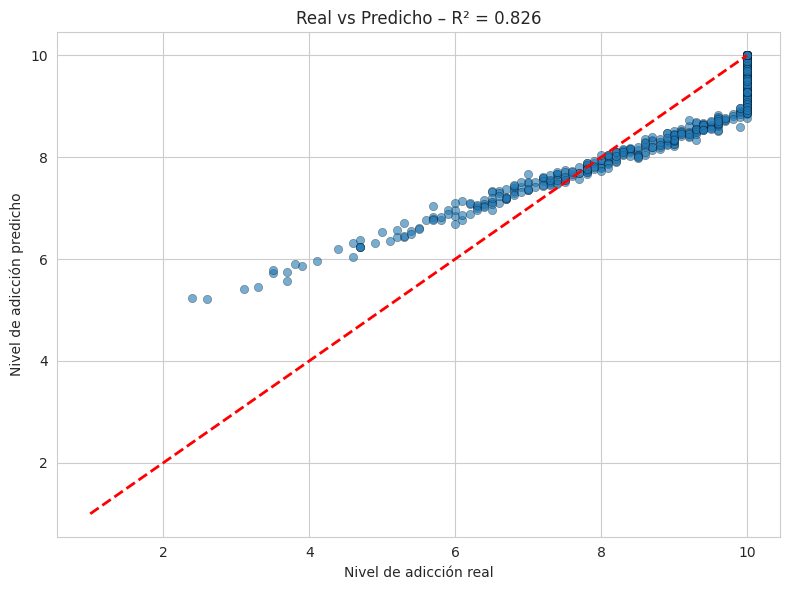

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Nivel de adicción real')
plt.ylabel('Nivel de adicción predicho')
plt.title(f'Real vs Predicho – R² = {r2:.3f}')
plt.grid(True)
plt.tight_layout()
plt.show()